✅ Data loaded successfully
X_train shape: (31311, 5015)
🚀 Training K-Means model...
✅ Model trained successfully!
🧠 Silhouette Score: 0.158

Confusion Matrix (for analysis only):
[[ 7781  6069]
 [10371  7090]]

🎨 Visualizing clusters using PCA (2D)...


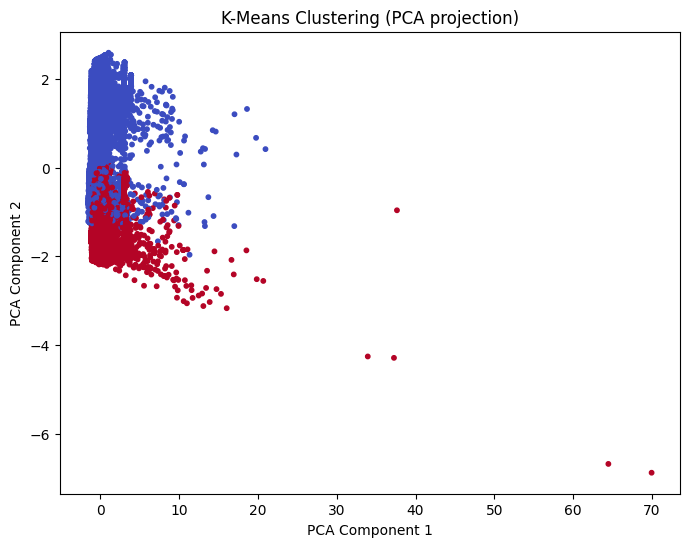


💾 K-Means model saved to artifacts/kmeans_model.joblib


In [1]:
# ============================================================
# 📘 Phase 3: Unsupervised Learning (K-Means Clustering)
# ============================================================

import joblib
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, silhouette_score
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1️⃣ Load preprocessed features from Phase 1
# ------------------------------------------------------------
data = joblib.load("artifacts/feature_data.joblib")

X_train = data["X_train"]   # نستخدم الخصائص فقط
y_train = data["y_train"]   # سنستخدمه لاحقًا فقط للمقارنة (تحليل)

print("✅ Data loaded successfully")
print("X_train shape:", X_train.shape)

# ------------------------------------------------------------
# 2️⃣ Apply K-Means clustering
# ------------------------------------------------------------
# نختار عدد الكلاسترات 2 لأن عندنا فئتين: spam / non-spam
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

print("🚀 Training K-Means model...")
kmeans.fit(X_train)
print("✅ Model trained successfully!")

# الحصول على التسميات التي أنشأها KMeans
cluster_labels = kmeans.labels_

# ------------------------------------------------------------
# 3️⃣ Evaluate clustering quality
# ------------------------------------------------------------
# نحسب الـ Silhouette Score لقياس جودة التجمعات
sil_score = silhouette_score(X_train, cluster_labels)
print(f"🧠 Silhouette Score: {sil_score:.3f}")

# نقارن الكلاستر مع الليبل الحقيقي فقط للتحليل (مو تدريب)
cm = confusion_matrix(y_train, cluster_labels)
print("\nConfusion Matrix (for analysis only):")
print(cm)

# ------------------------------------------------------------
# 4️⃣ Visualization (optional - using PCA to reduce to 2D)
# ------------------------------------------------------------
print("\n🎨 Visualizing clusters using PCA (2D)...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train.toarray())

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=cluster_labels, cmap='coolwarm', s=10
)
plt.title("K-Means Clustering (PCA projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# ------------------------------------------------------------
# 5️⃣ Save model (optional)
# ------------------------------------------------------------
joblib.dump(kmeans, "artifacts/kmeans_model.joblib")
print("\n💾 K-Means model saved to artifacts/kmeans_model.joblib")
